# Descrição do projeto

Os clientes do Beta Bank estão saindo: pouco a pouco, escapulindo todo mês. Os banqueiros descobriram que é mais barato manter os clientes existentes do que atrair novos.

Precisamos prever se um cliente vai deixar o banco em breve. Você tem os dados sobre o comportamento passado dos clientes e rescisões de contratos com o banco.

Construa um modelo com o valor máximo possível de F1. Para passar na revisão, você precisa de um F1-score de pelo menos 0,59 para o conjunto de dados de teste. 

Além disso, meça a métrica AUC-ROC e compare-a com o F1-score.

# Instruções do projeto

1.Baixe e prepare os dados. Certifique-se de explicar a lógica que você segue durante a preparação.


2.Examine o equilíbrio das classes. Treine o modelo sem levar em conta o desequilíbrio. Descreva brevemente suas descobertas.


3.Melhore a qualidade do modelo. Certifique-se de usar pelo menos duas abordagens para corrigir o desequilíbrio de classe. Use conjuntos de treinamento e validação para encontrar o melhor modelo e o melhor conjunto de parâmetros. Descreva brevemente suas descobertas.


4.Realize o teste final.

# Descrição de dados

Os dados podem ser encontrados no arquivo /datasets/Churn.csv. Faça o download do conjunto de dados.

**Características**
- RowNumber — índice das strings de dados
- CustomerId — identificador exclusivo do cliente
- Surname — sobrenome
- CreditScore — pontuação de crédito
- Geography — país de residência
- Gender — gênero
- Age — idade
- Tenure — período de maturação para o depósito fixo de um cliente (anos)
- Balance — saldo da conta
- NumOfProducts — número de produtos bancários usados pelo cliente
- HasCrCard — cliente possui cartão de crédito (1 - sim; 0 - não)
- IsActiveMember — cliente ativo (1 - sim; 0 - não)
- EstimatedSalary — salário estimado
  
**Objetivo**
- Exited — o cliente saiu (1 - sim; 0 - não)

# 1. Baixe e prepare os dados. Certifique-se de explicar a lógica que você segue durante a preparação.

In [3]:
# Importação de bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, precision_recall_curve, roc_curve, roc_auc_score
from sklearn.utils import shuffle

In [5]:
# Carregamento de arquivo .csv

data = pd.read_csv('Churn.csv')

In [6]:
# Informações Gerais do DataFrame

print('Informações Gerais')
data.info()

Informações Gerais
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 1.1 MB


In [7]:
# Exclusão de colunas que não irão gerar impacto em futuras análises

data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [8]:
# Verificando existencia de valores duplicados

print(data.duplicated().sum())

0


<br>Em análise prévia dos dados foi optado por não alterar os valores ausentes, pois poderiam causar problemas futuros ao trabalhar com modelos preditivos. Optou-se também a exclusão de algumas colunas que não se mostraram como características relevantes.

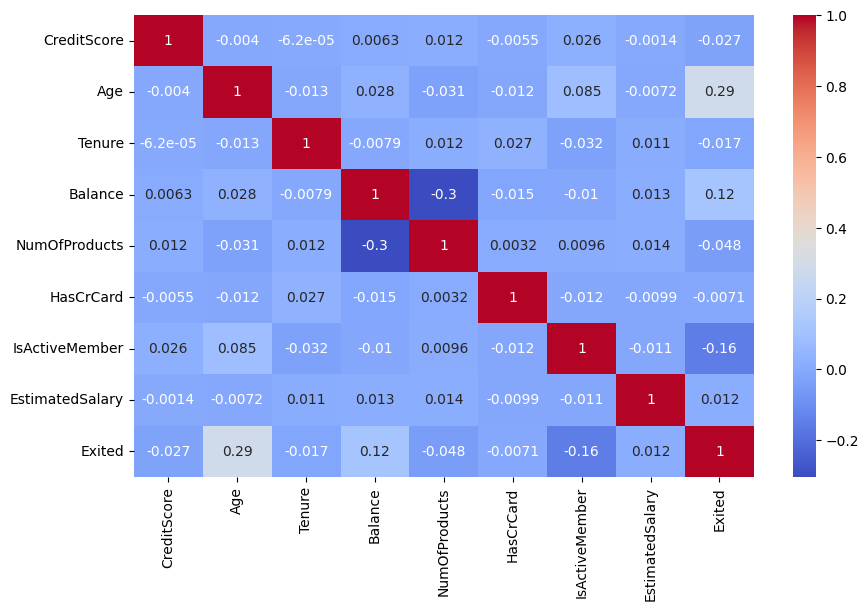

In [12]:
x = data.corr(numeric_only=True)

plt.figure(figsize=[10,6])
sns.heatmap(x, annot=True, cmap='coolwarm')
plt.show()

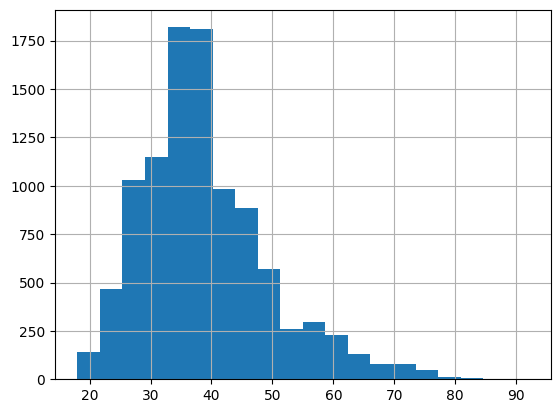

In [13]:
data['Age'].hist(bins=20)
plt.show()


# 2. Examine o equilíbrio das classes. Treine o modelo sem levar em conta o desequilíbrio. Descreva brevemente suas descobertas.

In [14]:
# transformação dos dados categóricos em numéricos

data = pd.get_dummies(data, columns=['Geography', 'Gender'])

In [15]:
# Substituiçaõ dos valores ausentes da coluna 'Tenure' pela mediana

data['Tenure'] = data['Tenure'].fillna(data['Tenure'].median())

<br><br>

Considerando que modelos preditivos não são capazes de processar valores nulos ou ausentes, tornou-se necessária a substituição desses registros. Embora a média e a mediana apresentassem valores bastante próximos, optou-se pela utilização da mediana, por se tratar de uma medida de tendência central mais robusta, menos sensível a valores extremos e outliers, garantindo maior estabilidade ao processo de treinamento do modelo.

In [16]:
# Percentual das Classes

data['Exited'].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [17]:
# Separação das variáveis (features, target)

features = data.drop('Exited', axis=1)
target = data['Exited']

In [18]:
# Divisão dos dados Treinamento e Validação.

features_train, features_valid, target_train, target_valid = train_test_split(features, target, test_size=0.25, random_state=12345, stratify=target)

<br><br>

## Treinando modelos sem manipulação do balanceamento de Classes

### Treinamento e análise com modelo DecisionTreeClassifier()

In [19]:

# Treinando modelo sem considerar equilíbrio das classes



model = DecisionTreeClassifier(random_state=12345)
model.fit(features_train, target_train)



predicted_valid = model.predict(features_valid)

print('Acurácia modelo Árvore de Decisão: \n', accuracy_score(target_valid, predicted_valid))
print()
print('Matriz de Confusao: \n', confusion_matrix(target_valid, predicted_valid))
print()
print('Sensibilidade: ', recall_score(target_valid, predicted_valid))
print()
print('Precisão: ', precision_score(target_valid, predicted_valid))
print()
print('F1-Score: ', f1_score(target_valid, predicted_valid))
print()



Acurácia modelo Árvore de Decisão: 
 0.7948

Matriz de Confusao: 
 [[1717  274]
 [ 239  270]]

Sensibilidade:  0.5304518664047151

Precisão:  0.4963235294117647

F1-Score:  0.5128205128205128



### Treinamento e análise com modelo RandomForestClassifier()

In [20]:
m1 = RandomForestClassifier(random_state=12345, n_estimators=10)
m1.fit(features_train, target_train)

p_valid = m1.predict(features_valid)

print('Acurácia Modelo - RandomForest: ', accuracy_score(target_valid, p_valid))
print()
print('Matriz de Confusao: \n', confusion_matrix(target_valid, p_valid))
print()
print('Sensibilidade: ', recall_score(target_valid, p_valid))
print()
print('Precisão: ', precision_score(target_valid, p_valid))
print()
print('F1-Score: ', f1_score(target_valid, p_valid))
print()


Acurácia Modelo - RandomForest:  0.8472

Matriz de Confusao: 
 [[1901   90]
 [ 292  217]]

Sensibilidade:  0.4263261296660118

Precisão:  0.7068403908794788

F1-Score:  0.5318627450980392



### Treinamento e análise com modelo LogisticRegression()

In [21]:

m2 = LogisticRegression(random_state=12345)
m2.fit(features_train, target_train)

p_logistic_regression = m2.predict(features_valid)

print('Acurácia Modelo - LogisticRegression: ', accuracy_score(target_valid, p_logistic_regression))
print()
print('Matriz de Confusao: \n', confusion_matrix(target_valid, p_logistic_regression))
print()
print('Sensibilidade: ', recall_score(target_valid, p_logistic_regression))
print()
print('Precisão: ', precision_score(target_valid, p_logistic_regression))
print()
print('F1-Score: ', f1_score(target_valid, p_logistic_regression))
print()



Acurácia Modelo - LogisticRegression:  0.7904

Matriz de Confusao: 
 [[1941   50]
 [ 474   35]]

Sensibilidade:  0.068762278978389

Precisão:  0.4117647058823529

F1-Score:  0.11784511784511785



c:\Users\drial\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<br><br>
#### Análise Geral do modelos de treinamento

Considerando o desbalanceamento proposital das classes (79,63% não churn e 20,37% churn), a acurácia isolada mostrou-se insuficiente para avaliar os modelos. 

A Regressão Logística apresentou desempenho insatisfatório na identificação da classe minoritária, sendo descartada. 

A Árvore de Decisão demonstrou maior capacidade de identificar clientes que abandonam o serviço, enquanto o Random Forest apresentou melhor desempenho geral, com maior F1-score e precisão. 

A escolha do modelo mais adequado depende do objetivo do negócio, sendo a Árvore de Decisão indicada para maximizar a detecção de churn e o Random Forest para decisões mais conservadoras.

<br><br>

# 3. Melhore a qualidade do modelo. Certifique-se de usar pelo menos duas abordagens para corrigir o desequilíbrio de classe. Use conjuntos de treinamento e validação para encontrar o melhor modelo e o melhor conjunto de parâmetros. Descreva brevemente suas descobertas.

In [22]:
# Ajuste de ponderação de Classe - Superamostragem

def upsample(features, target, repeat):
    features_zeros = features_train[target_train == 0]
    features_ones = features_train[target_train == 1]
    target_zeros = target_train[target_train == 0]
    target_ones = target_train[target_train == 1]

    arg1 = pd.concat([features_zeros] + [features_ones] * repeat)
    arg2 = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(arg1, arg2, random_state=12345)

    return features_upsampled, target_upsampled


# Chamada da função
features_upsampled, target_upsampled = upsample(features_train, target_train, 4)

print(features_upsampled.shape)
print(target_upsampled.shape)


(12084, 13)
(12084,)


In [23]:
target_upsampled.value_counts(normalize=True) * 100

Exited
1    50.579278
0    49.420722
Name: proportion, dtype: float64

Acurácia modelo Árvore de Decisão: 
 0.8

Matriz de Confusao: 
 [[1746  245]
 [ 255  254]]

Sensibilidade:  0.49901768172888017

Precisão:  0.5090180360721442

F1-Score:  0.503968253968254

Ajuste de Limiar [0 1 0 ... 0 0 0]
Curva ROC: 
 (array([0.        , 0.12305374, 1.        ]), array([0.        , 0.49901768, 1.        ]), array([inf,  1.,  0.]))

Curva AUC-ROC: 
 0.687981969945304




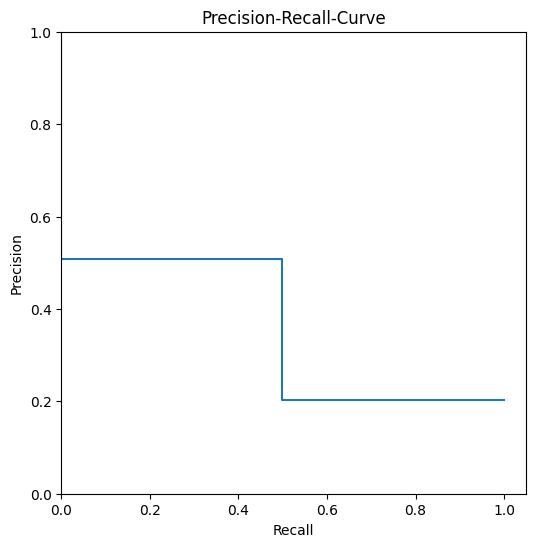

In [24]:
model = DecisionTreeClassifier(random_state=12345, class_weight='balanced')
model.fit(features_upsampled, target_upsampled)

predicted_valid = model.predict(features_valid)

print('Acurácia modelo Árvore de Decisão: \n', accuracy_score(target_valid, predicted_valid))
print()
print('Matriz de Confusao: \n', confusion_matrix(target_valid, predicted_valid))
print()
print('Sensibilidade: ', recall_score(target_valid, predicted_valid))
print()
print('Precisão: ', precision_score(target_valid, predicted_valid))
print()
print('F1-Score: ', f1_score(target_valid, predicted_valid))
print()


# AJUSTE DE LIMIAR
probab_valid = model.predict_proba(features_valid)[ : , 1]
y_pred = (probab_valid >= 0.35).astype(int)
print('Ajuste de Limiar', y_pred)

# Curva PR
precision, recall, thresholders = precision_recall_curve(target_valid, probab_valid)

plt.figure(figsize=(6, 6))
plt.step(recall, precision, where='post')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt. xlim([0.0, 1.05])
plt.ylim([0.0, 1.0])
plt.title('Precision-Recall-Curve')
plt.show

# Curva ROC
print('Curva ROC: \n', roc_curve(target_valid, y_pred))

print()

# Curva AUC-ROC
print('Curva AUC-ROC: \n', roc_auc_score(target_valid, y_pred))

print()
print()

Acurácia Modelo - RandomForest:  0.8224

Matriz de Confusao: 
 [[1723  268]
 [ 176  333]]

Sensibilidade:  0.6542239685658153

Precisão:  0.5540765391014975

F1-Score:  0.6

Ajuste de Limiar [0 1 1 ... 0 0 0]
Curva ROC: 
 (array([0.        , 0.26167755, 1.        ]), array([0.        , 0.81335953, 1.        ]), array([inf,  1.,  0.]))

Curva AUC-ROC: 
 0.7758409897584315




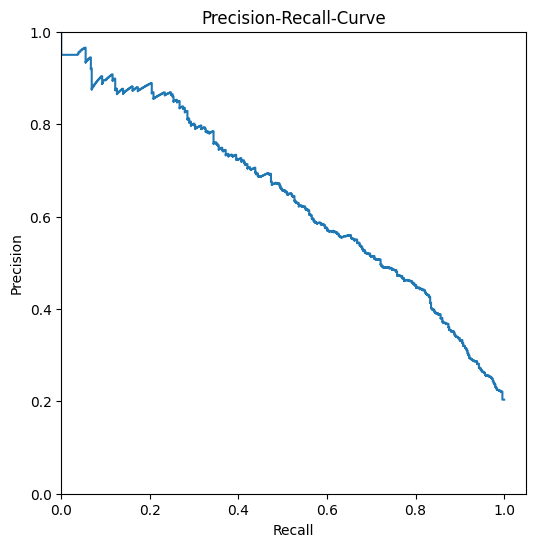

In [25]:
# RandomForest

m1 = RandomForestClassifier(random_state=12345, n_estimators=10, class_weight='balanced', min_samples_leaf = 5)
m1.fit(features_upsampled, target_upsampled)

p_valid = m1.predict(features_valid)

print('Acurácia Modelo - RandomForest: ', accuracy_score(target_valid, p_valid))
print()
print('Matriz de Confusao: \n', confusion_matrix(target_valid, p_valid))
print()
print('Sensibilidade: ', recall_score(target_valid, p_valid))
print()
print('Precisão: ', precision_score(target_valid, p_valid))
print()
print('F1-Score: ', f1_score(target_valid, p_valid))
print()

# AJUSTE DE LIMIAR
probab_valid = m1.predict_proba(features_valid)[ : , 1]
y_pred = (probab_valid >= 0.35).astype(int)
print('Ajuste de Limiar', y_pred)

# Curva PR
precision, recall, thresholders = precision_recall_curve(target_valid, probab_valid)

plt.figure(figsize=(6, 6))
plt.step(recall, precision, where='post')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt. xlim([0.0, 1.05])
plt.ylim([0.0, 1.0])
plt.title('Precision-Recall-Curve')
plt.show

# Curva ROC
print('Curva ROC: \n', roc_curve(target_valid, y_pred))

print()

# Curva AUC-ROC
print('Curva AUC-ROC: \n', roc_auc_score(target_valid, y_pred))

print()
print()


Acurácia Modelo - LogisticRegression:  0.6608

Matriz de Confusao: 
 [[1302  689]
 [ 159  350]]

Sensibilidade:  0.68762278978389

Precisão:  0.3368623676612127

F1-Score:  0.45219638242894056

Ajuste de Limiar [1 1 1 ... 0 0 1]
Curva ROC: 
 (array([0.        , 0.67202411, 1.        ]), array([0.        , 0.90569745, 1.        ]), array([inf,  1.,  0.]))

Curva AUC-ROC: 
 0.6168366687421492




c:\Users\drial\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


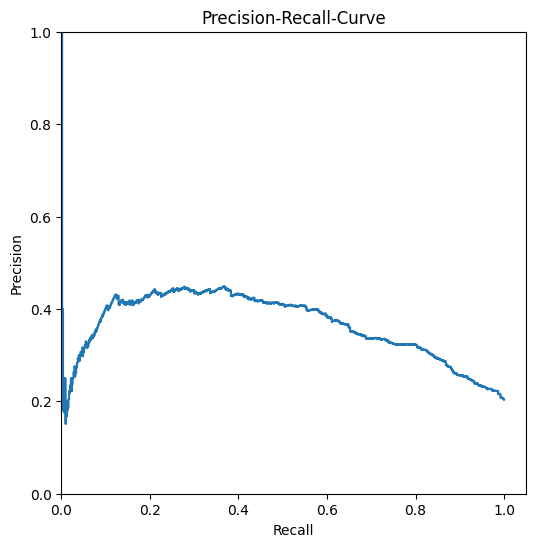

In [26]:
m2 = LogisticRegression(random_state=12345, class_weight='balanced')
m2.fit(features_train, target_train)

p_logistic_regression = m2.predict(features_valid)

print('Acurácia Modelo - LogisticRegression: ', accuracy_score(target_valid, p_logistic_regression))
print()
print('Matriz de Confusao: \n', confusion_matrix(target_valid, p_logistic_regression))
print()
print('Sensibilidade: ', recall_score(target_valid, p_logistic_regression))
print()
print('Precisão: ', precision_score(target_valid, p_logistic_regression))
print()
print('F1-Score: ', f1_score(target_valid, p_logistic_regression))
print()

# AJUSTE DE LIMIAR
probab_valid = m2.predict_proba(features_valid)[ : , 1]
y_pred = (probab_valid >= 0.35).astype(int)
print('Ajuste de Limiar', y_pred)

# Curva PR
precision, recall, thresholders = precision_recall_curve(target_valid, probab_valid)

plt.figure(figsize=(6, 6))
plt.step(recall, precision, where='post')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt. xlim([0.0, 1.05])
plt.ylim([0.0, 1.0])
plt.title('Precision-Recall-Curve')
plt.show

# Curva ROC
print('Curva ROC: \n', roc_curve(target_valid, y_pred))

print()

# Curva AUC-ROC
print('Curva AUC-ROC: \n', roc_auc_score(target_valid, y_pred))

print()
print()

<br><br>
# 4. Testes final

In [27]:
y_prob = m1.predict_proba(features_valid)[:, 1]

thresholds = [i/100 for i in range(20, 80)]
f1_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(target_valid, y_pred))

best_t = thresholds[f1_scores.index(max(f1_scores))]
best_f1 = max(f1_scores)

best_t, best_f1


(0.49, 0.6023029229406555)

Aqui fizemos ajustes com o intuito de melhorar o F1-score do modelo RandomForest, modelo que vinha se destacando. 

<br><br>

# 4. Considerações finais

Baseado no objetivo de prever se um cliente vai deixar o banco em breve, o modelo que possue as métricas mais robustas é o RandomForest.

O modelo Random Forest foi selecionado por apresentar o melhor equilíbrio entre capacidade discriminativa (AUC-ROC), precisão e F1-Score, sendo mais adequado ao objetivo de prever a evasão de clientes e apoiar ações de retenção com maior eficiência.